In [2]:
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
"""
This is a table to create points on a graph

Point , x1, x2, class

A       2    3    0
B       3    4    0
C       4    3    0
D       7    6    1
E       8    7    1
F       9    6    1
""";

In [4]:
x1 = np.array([2,3,4,7,8,9])
x2 = np.array([3,4,3,6,7,6])

In [5]:
A = np.array([x1[0],x2[0]])
B = np.array([x1[1],x2[1]])
C = np.array([x1[2],x2[2]])
D = np.array([x1[3],x2[3]])
E = np.array([x1[4],x2[4]])
F = np.array([x1[5],x2[5]])

In [6]:
# class zero mean
u_0 = np.array([(2+3+4)/3, (3+4+3)/3])
u_0

array([3.        , 3.33333333])

In [7]:
# class 1 mean
u_1 = np.array([(7+8+9)/3, (6+7+6)/3])
u_1

array([8.        , 6.33333333])

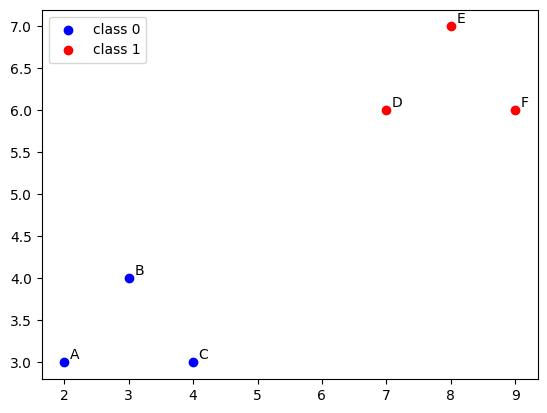

In [8]:
plt.scatter(x1[:3], x2[:3], c='blue', label='class 0')
plt.scatter(x1[3:], x2[3:], c='red', label='class 1')
plt.legend()

labels = ['A', 'B', 'C', 'D', 'E', 'F']

for i, label in enumerate(labels):
    plt.annotate(label, (x1[i], x2[i]), textcoords="offset points", xytext=(4, 3))

plt.show()

In [9]:
# how much A deviates from the mean of its class
A_deviation = A - u_0

# calculates the outer product between A_deviation and its transpose
A_outer_product = np.outer(A_deviation,A_deviation.T)

In [10]:
B_deviation = B - u_0
B_outer_product = np.outer(B_deviation,B_deviation.T)

In [11]:
C_deviation = C - u_0
C_outer_product = np.outer(C_deviation,C_deviation.T)

In [12]:
D_deviation = D - u_1
D_outer_product = np.outer(D_deviation,D_deviation.T)

In [13]:
E_deviation = E - u_1
E_outer_product = np.outer(E_deviation,E_deviation.T)

In [14]:
F_deviation = F - u_1
F_outer_product = np.outer(F_deviation,F_deviation.T)

In [15]:
# S_0 = scatter (spread) of class 0 points around their mean

# upper left is spread in x1 and bottom right is spread in x2
S_0 = A_outer_product + B_outer_product + C_outer_product
S_0

array([[2.        , 0.        ],
       [0.        , 0.66666667]])

In [16]:
# S_1 = scatter (spread) of class 1 points around their mean
S_1 = D_outer_product + E_outer_product + F_outer_product
display(S_1)
display("You can see that S_0 and S_1 are the same, thus, there is no correlation " \
"between them. ")

array([[2.        , 0.        ],
       [0.        , 0.66666667]])

'You can see that S_0 and S_1 are the same, thus, there is no correlation between them. '

In [17]:
# S_W is within class scatter matrix
S_W = S_0 + S_1
S_W

array([[4.        , 0.        ],
       [0.        , 1.33333333]])

In [18]:
# S_B measures how far apart the class means are
mean_diff = np.array([u_1[0] - u_0[0], u_1[1] - u_0[1]])
# S_B, between class scatter matrix
S_B = np.outer(mean_diff, mean_diff.T)

print("mean_diff: ", mean_diff)
print("This means the the class means are 5 units apart" \
" in x1 and 3 units apart in x2")
print("S_B: ", S_B)

mean_diff:  [5. 3.]
This means the the class means are 5 units apart in x1 and 3 units apart in x2
S_B:  [[25. 15.]
 [15.  9.]]


In [19]:
s_w_inv = np.linalg.inv(S_W)
s_w_inv

array([[0.25, 0.  ],
       [0.  , 0.75]])

In [20]:
sol = np.dot(s_w_inv, S_B)
sol

array([[ 6.25,  3.75],
       [11.25,  6.75]])

In [21]:
eigenvalues, eigenvectors = np.linalg.eig(np.dot(s_w_inv, S_B))
print(eigenvalues, "\n")
print(eigenvectors)

[8.8817842e-16 1.3000000e+01] 

[[-0.51449576 -0.48564293]
 [ 0.85749293 -0.87415728]]


In [22]:
"""
this is grabbing the eigenvector that is associated with the largest eigenvalue. In this case the largest
eigenvalue is the second element in eigenvalues. Thus we want the second element in each of the arrays inside 
of eigenvectors.
"""

w = eigenvectors[:,1]
w

array([-0.48564293, -0.87415728])

In [23]:
"""
calculate the midpoint on the decision boundary, decision boundary is the line we have created

we calculate the dot product between the mean of each class and w, add them together and divide by 2
to get the midpoint/threshold
"""
proj_u0 = np.dot(u_0, w)
proj_u1 = np.dot(u_1, w)
threshold = (proj_u0 + proj_u1) / 2

print("Class 0: ")
print(np.dot(A,w))
print(np.dot(B,w))
print(np.dot(C,w), '\n')
print("midpoint/threshold = ",threshold, "\n")
print("Class 1: ")
print(np.dot(D,w))
print(np.dot(E,w))
print(np.dot(F,w))



Class 0: 
-3.5937576907218776
-4.953557898022048
-4.565043553079143 

midpoint/threshold =  -6.896129622736577 

Class 1: 
-8.644444174979652
-10.004244382279822
-9.615730037336917


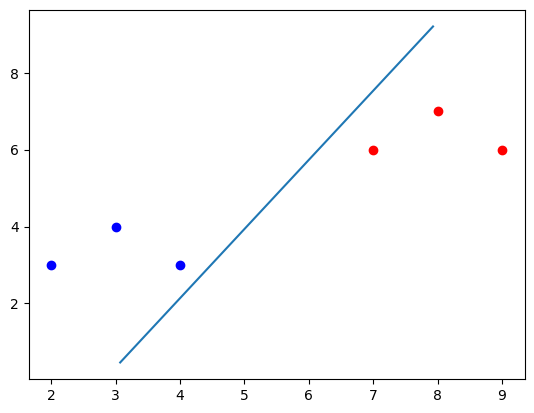

In [24]:
center = np.add(u_0, u_1)
center = center / 2
p1 = center - 5 * w
p2 = center + 5 * w
plt.plot([p1[0], p2[0]], [p1[1], p2[1]])
plt.scatter([2,3,4], [3,4,3], color='blue', label='Class 0')
plt.scatter([7,8,9], [6,7,6], color='red', label='Class 1')
plt.show()